# Постановка задачи

Целью данной работы является автоматическая кластеризация сигналов, полученных со сцинтилляционного детектора, на основе их параметров. Необходимо разделить 23 479 сигналов на три кластера: два из них соответствуют различным типам частиц (гамма-кванты и нейтроны), а третий — группе аномальных или неидентифицируемых сигналов.
Задача решается методами машинного обучения без учителя с последующей интерпретацией результатов кластеризации.

# Контекст задачи

Датасет это 500 временных отчетов, с шагом по времени 2 ns, со значением напряжения на сцинтилляционном детекторе. Сам сигнал помещается примерно в 140-180 индексы, то есть полезное измерение от 280 ns до 360 ns. В зависимости от времени затухания сигнала, можно определить тип частицы: гамма-кванты имеют более длительный спад сигнала. Если же максим сигнала представляет собой не одну точку, а плато, это означает, что сигнал был мощее, чем максимум измерительного прибора и такой сигнал можно определить к аномальному.

Чем больше аплитуда, тем проще распознать сигнал. А при снижении энергии частиц отличить гаммы-кванты от нейтронов становится все сложнее.

Фронт сигнала - время от начала сигнала до максимального значения.
Спад сигнала - время от максимального значения до завершения сигнала.

Относительное(у разных сигналов разная длительность) время возрастания сигнала примерно одинаковое у всех. Поэтому фронты сигнала и амплитуды могут совпадать у сигналов разных частиц, но время затухания будет отличаться. Это при условии, что мы учитываем масштаб.

# Импорт библиотек

In [8]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import itertools

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

# Считывание даннных

In [10]:
dataset = pd.read_csv('../data/scintillation-detector/Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)
# метаданные, описывающие состояние ФЭУ в момент получения сигнала
dataset.drop([0, 1, 2, 3], axis=1, inplace=True)
# пустой признак
dataset.drop([504], axis=1, inplace=True)

dataset.columns = list(range(500))

# Напряжение фиксируется отрицательным, поэтому импульсы направлены вниз. Инвертируем значения для удобства.
dataset = dataset.max().max() - dataset
dataset.shape

(23479, 500)

# Исследование и анализ датасета

## Статистический анализ

In [13]:
dataset.head()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,18,15,14,16,20,18,14,16,18,18,...,10,16,23,23,21,19,18,16,18,19
1,18,16,18,12,14,16,18,16,15,17,...,10,21,14,16,14,19,18,19,16,18
2,18,18,16,13,18,14,14,19,15,14,...,18,17,18,18,20,17,15,18,18,17
3,10,16,20,14,14,16,18,16,14,18,...,14,12,16,17,18,10,18,16,15,16
4,15,23,15,17,11,18,15,14,22,17,...,18,18,15,10,14,18,14,14,16,13


In [14]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Columns: 500 entries, 0 to 499
dtypes: int64(500)
memory usage: 89.6 MB


In [15]:
pd.set_option('display.max_columns', 500)
dataset.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499
count,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.00000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.00000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.00000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,

Пропусков и выбросов в данных нет. Стандартизация/нормализация не требуется.

## Визуализация данных

Text(0, 0.5, 'bit ADC')

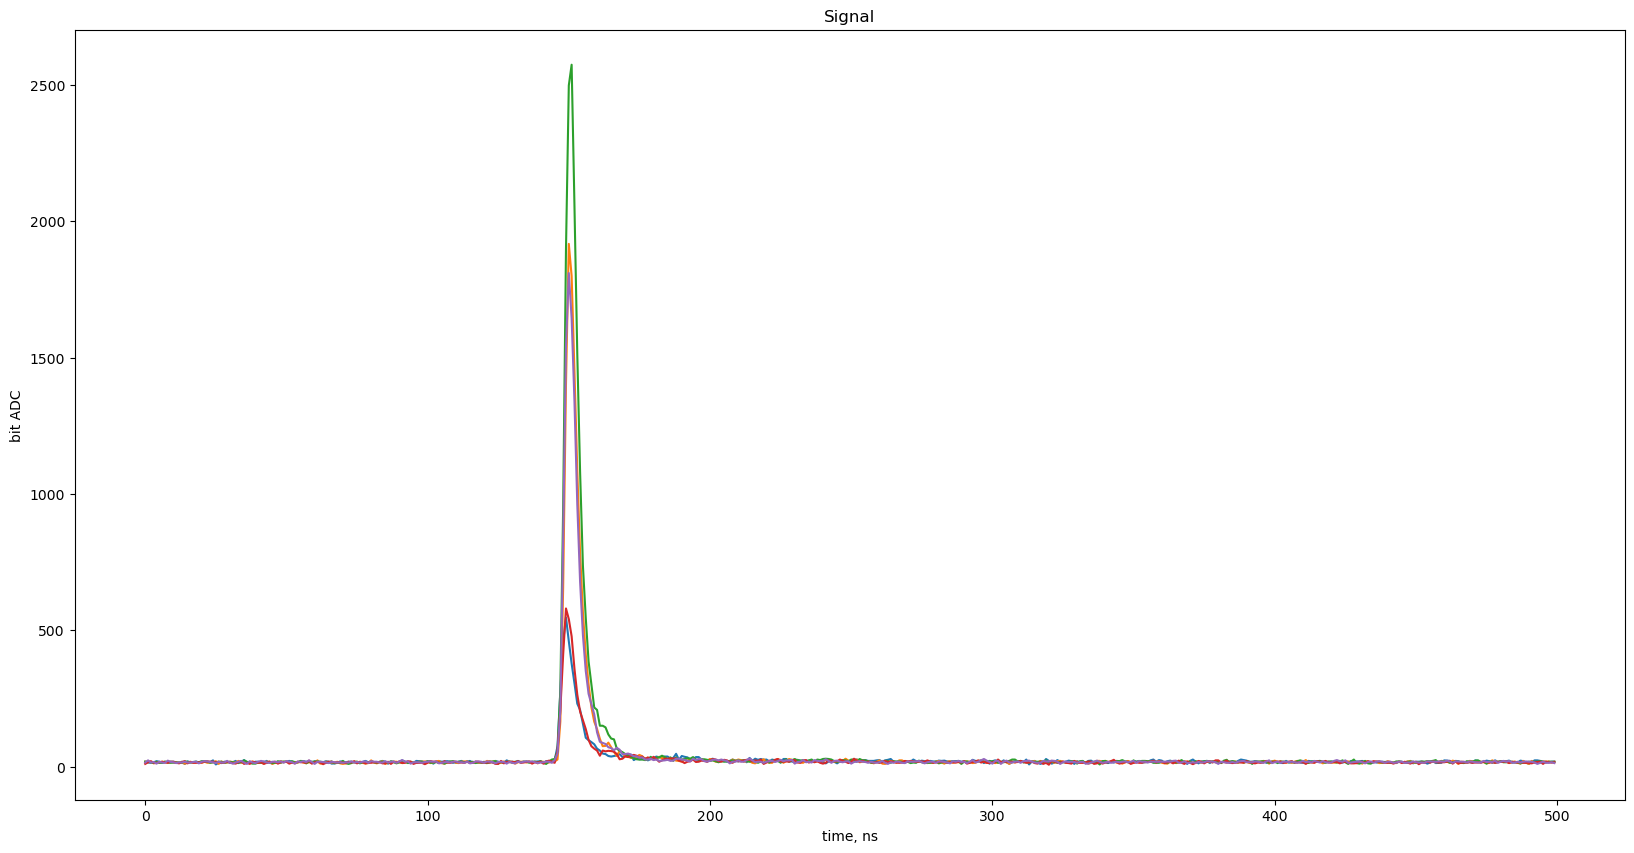

In [18]:
N=range(0,5)
ax = dataset.T[N].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")

Text(0, 0.5, 'bit ADC')

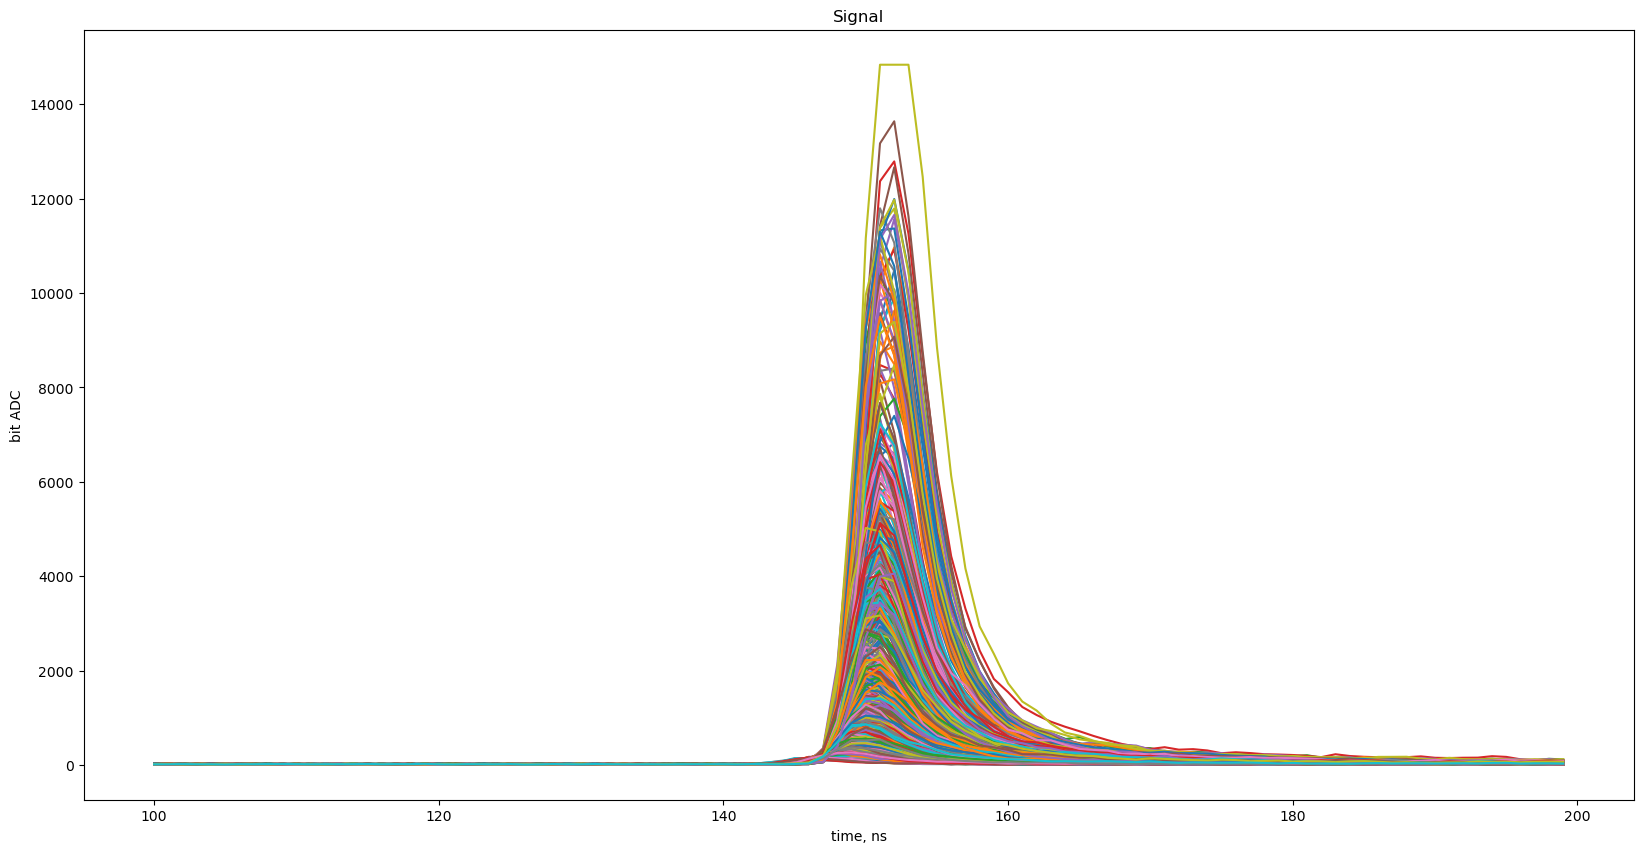

In [19]:
N=range(0,1000)
ax = dataset.T[N][100:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")

Text(0, 0.5, 'bit ADC')

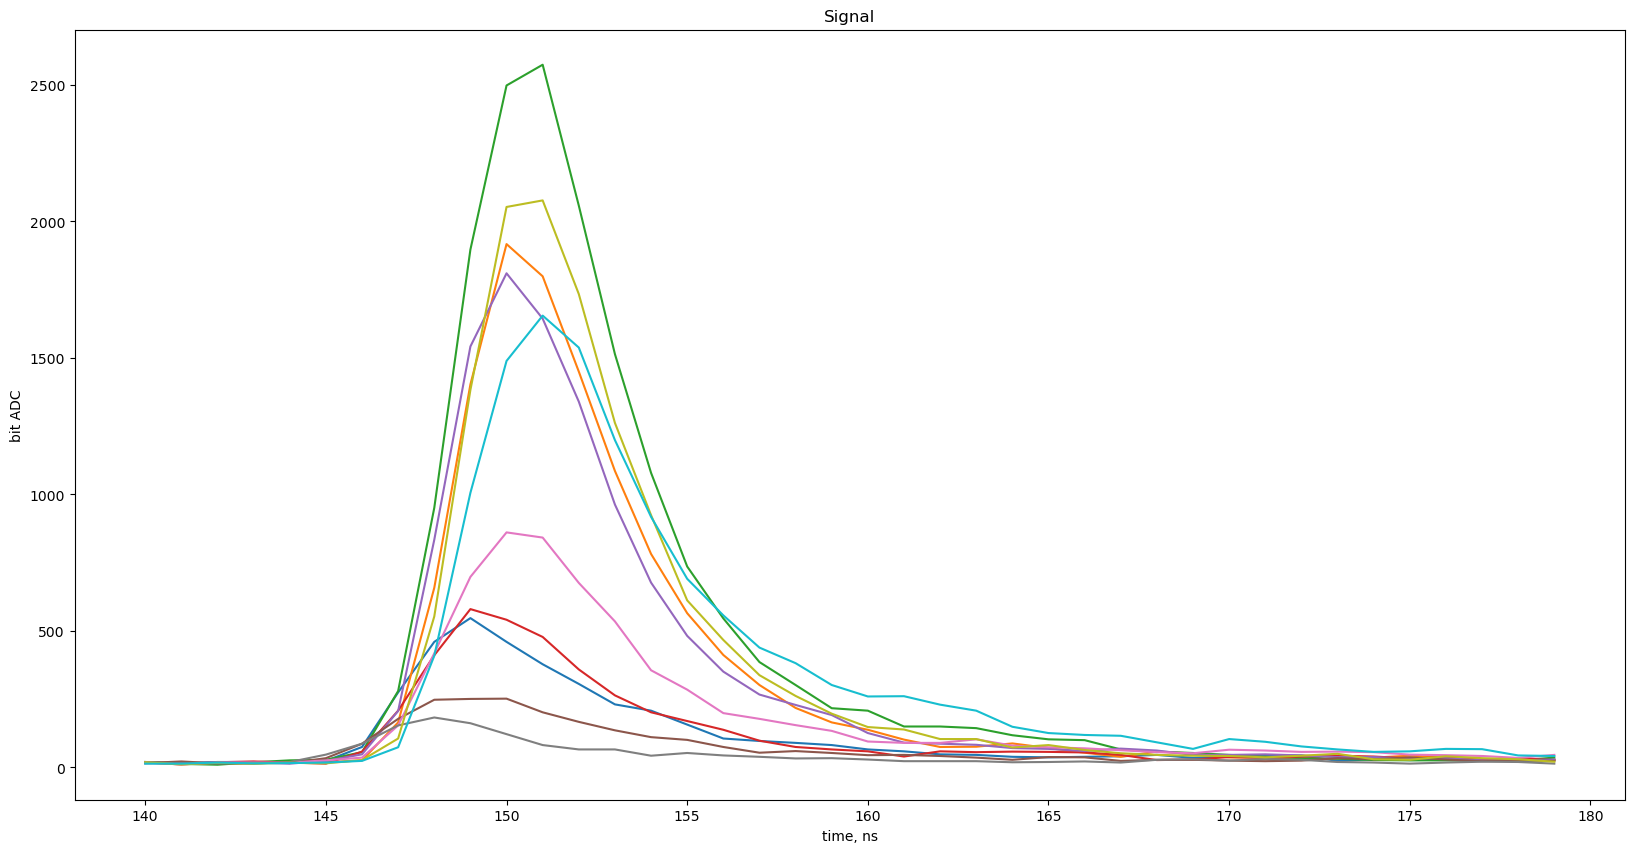

In [20]:
N=range(0,10)
ax = dataset.T[N][140:180].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")

# Обработка сигналов

## Выделение сигнала

Чтобы выделить сигнал, надо выделить нулевую линию, где сигнала еще нет. И уровень фона. Если считать что шум распределен по нормальному закону, можно считать что граница по которой мы считаем что сигнал испустился и поглотился это нулевая линия + 3 стандартных отклонения. Для каждого сигнала(у нас их 23479) своя нулевая линия и стандартное отклонение.

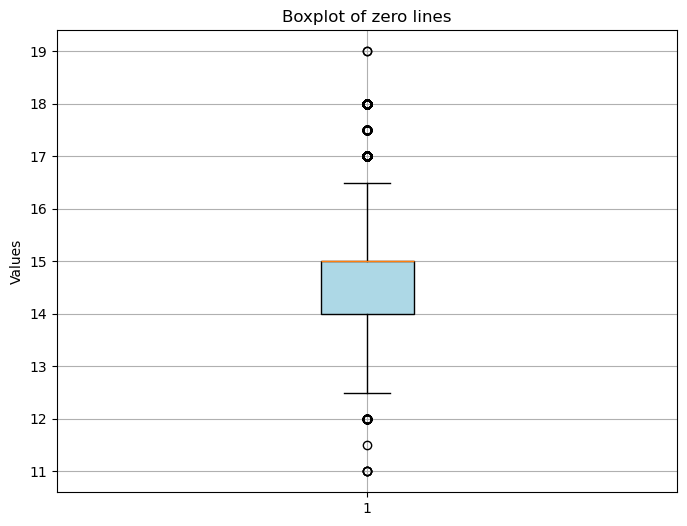

In [24]:
df_first = dataset.iloc[:, :100]
zero_lines = df_first.median(axis=1)

plt.figure(figsize=(8, 6))
plt.boxplot(zero_lines, vert=True, patch_artist=True, boxprops=dict(facecolor="lightblue"))
plt.title("Boxplot of zero lines")
plt.ylabel("Values")
plt.grid(True)
plt.show()

In [25]:
stds = dataset.std(axis=1)
max_indices = dataset.idxmax(axis=1).astype(int)

START_OFFSET = 2
END_OFFSET = 8

def find_pulse_start(row):
    end_index = max_indices[row.name]
    zero_line = zero_lines[row.name]
    std = stds[row.name]
    
    threshold = zero_line + 1.5 * std
    start_index = 0
    under_threshold_count = 0
    # Количество шагов выше порога, чтобы считать нарастание начавшимся
    under_threshold_limit = 1
    
    for i in range(0, end_index):
        if row[i] > threshold:
            under_threshold_count += 1
            if under_threshold_count > under_threshold_limit:
                break
        else:
            under_threshold_count = 0
        start_index = i
    return start_index - START_OFFSET

def find_pulse_end(row):
    start_index = max_indices[row.name]
    zero_line = zero_lines[row.name]
    std = stds[row.name]
    
    threshold = zero_line + 2.5 * std
    end_index = start_index
    below_threshold_count = 0
    # Количество шагов ниже порога, чтобы считать затухание завершенным
    below_threshold_limit = 5

    for i in range(end_index, len(row)):
        if row[i] < threshold:
            below_threshold_count += 1
            if below_threshold_count > below_threshold_limit:
                break
        else:
            below_threshold_count = 0
        end_index = i
    return end_index + END_OFFSET

pulse_starts = dataset.apply(lambda row: find_pulse_start(row), axis=1)
pulse_ends = dataset.apply(lambda row: find_pulse_end(row), axis=1)

pulses = []
for i in range(len(dataset)):
    start = pulse_starts[i]
    end = pulse_ends[i]       
    pulses.append(dataset.iloc[i, start:end + 1].values)

In [26]:
lengths = [len(pulse) for pulse in pulses]
average_length = sum(lengths) / len(lengths)
print(f'Средняя количество записей выделенного сигнала {round(average_length)}')

Средняя количество записей выделенного сигнала 24


Визуализируем на одном графике полную запись сигнала и выделенный импульс. Воспользуемся тем, что индексы у dataset и pulses не совпадают, поэтому графики не перекроют друг друга.

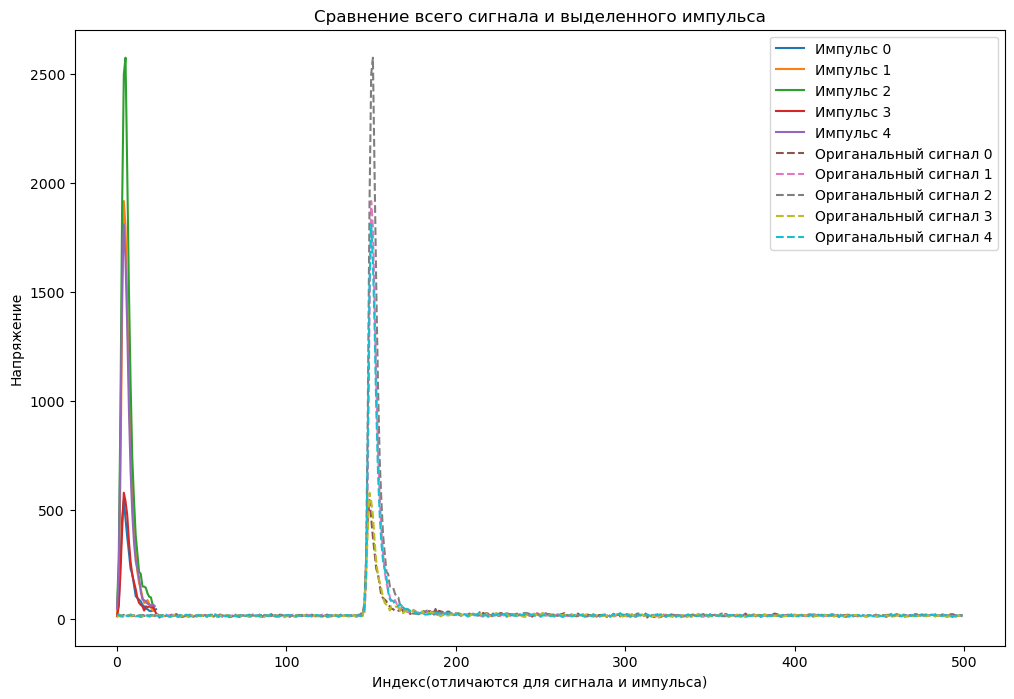

In [28]:
num_signals_to_plot = 5
plt.figure(figsize=(12, 8))

for i in range(num_signals_to_plot):
    plt.plot(pulses[i], label=f'Импульс {i}')
for i in range(num_signals_to_plot):
    plt.plot(dataset.iloc[i].values, label=f'Ориганальный сигнал {i}', linestyle='--')

plt.title('Сравнение всего сигнала и выделенного импульса')
plt.xlabel('Индекс(отличаются для сигнала и импульса)')
plt.ylabel('Напряжение')
plt.legend()
plt.show()

Выделим отдельно период нарастания и период затухания:

In [30]:
rising_impulses = []
falling_impulses = []
for i, pulse in enumerate(pulses):
    max_voltage = dataset.iloc[i, max_indices[i]]
    max_index = np.where(pulse == max_voltage)[0][0]
    if max_index < len(pulse):
        rising_impulse = pulse[:max_index+1]
    else:
        rising_impulse = pulse[:max_index]
    falling_impulse = pulse[max_index:]
    rising_impulses.append(rising_impulse)
    falling_impulses.append(falling_impulse)

Визуализируем отдельно нарастание:

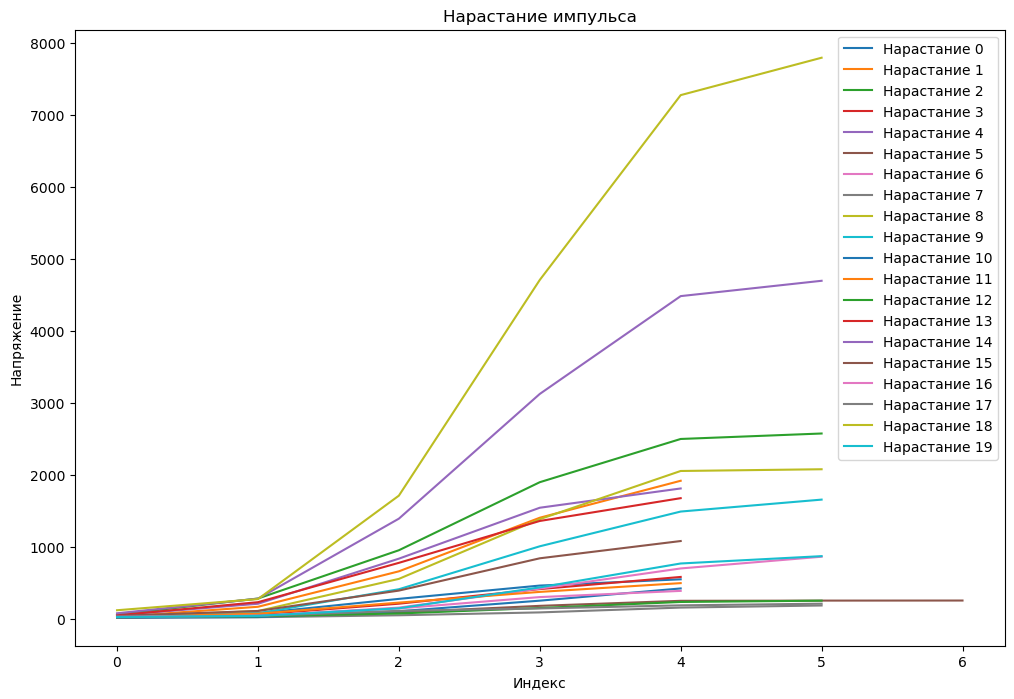

In [32]:
num_signals_to_plot = 20
plt.figure(figsize=(12, 8))

for i in range(num_signals_to_plot):
    plt.plot(rising_impulses[i], label=f'Нарастание {i}')
    
plt.title('Нарастание импульса')
plt.xlabel('Индекс')
plt.ylabel('Напряжение')
plt.legend()
plt.show()

Визуализируем отдельно затухание:

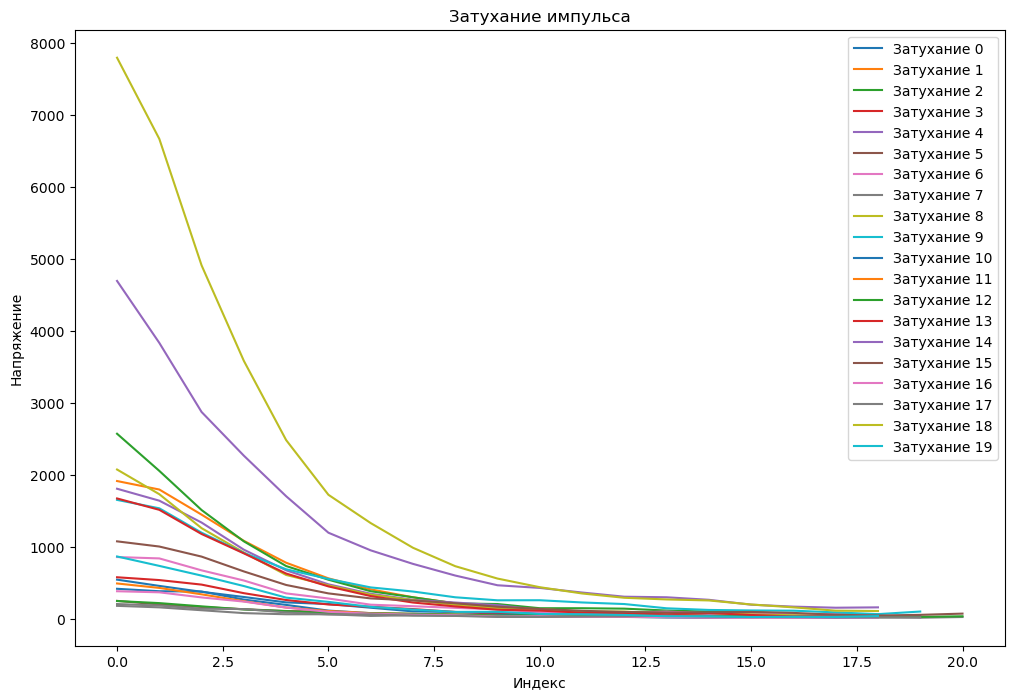

In [34]:
num_signals_to_plot = 20
plt.figure(figsize=(12, 8))

for i in range(num_signals_to_plot):
    plt.plot(falling_impulses[i], label=f'Затухание {i}')
    
plt.title('Затухание импульса')
plt.xlabel('Индекс')
plt.ylabel('Напряжение')
plt.legend()
plt.show()

Таким образом мы сильно уменьшили размерность исходных данных:

In [36]:
total_records_in_pulses = sum(len(pulse) for pulse in pulses)
total_records_in_dataset = dataset.size
percentage_difference = (total_records_in_dataset - total_records_in_pulses) / total_records_in_dataset * 100

print(f"Количество записей в списке списков: {total_records_in_pulses}")
print(f"Количество записей в DataFrame: {total_records_in_dataset}")
print(f"Записей в списке меньше на {percentage_difference:.2f}%")

Количество записей в списке списков: 569101
Количество записей в DataFrame: 11739500
Записей в списке меньше на 95.15%


Причем были проведены замеры на Kaggle:
* score на всем dataset для Kmeans - 0.34895
* только для `pd.DataFrame(pulses).fillna(0)` - 0.34929

что подтверждает, что при уменьшении размерности на 90+% мы не потеряли значимую информацию.

## Выделение аномальных сигналов

Можем сразу идентифицировать аномалии - те импульсы, у которых максимум достигается больше одного раза.

In [40]:
anomaly_indexes = []
for i, pulse in enumerate(pulses):
    max_voltage = dataset.iloc[i, max_indices[i]]
    max_indices_in_pulse = np.where(pulse == max_voltage)[0]
    
    if len(max_indices_in_pulse) > 1:
        anomaly_indexes.append(i)

print(f'Аномальных сигналов: {len(anomaly_indexes)}')

Аномальных сигналов: 212


Визуализируем аномальные сигналы:

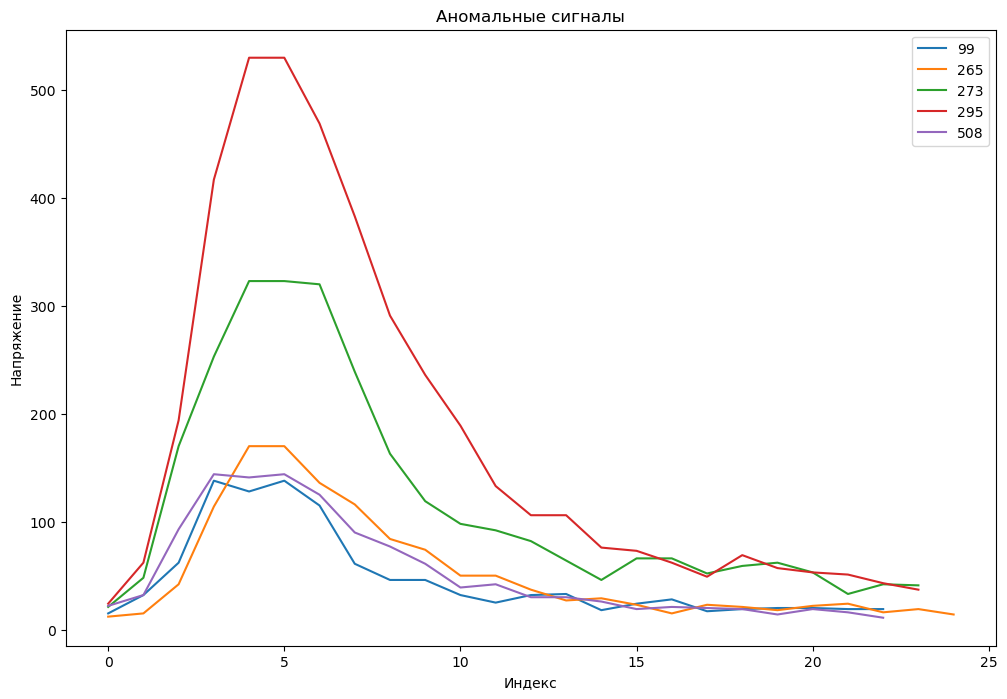

In [42]:
num_signals_to_plot = 5
plt.figure(figsize=(12, 8))

for i, anomaly_index in enumerate(anomaly_indexes):
    if i >= num_signals_to_plot:
        break
    plt.plot(pulses[anomaly_index], label=f'{anomaly_index}')

plt.title('Аномальные сигналы')
plt.xlabel('Индекс')
plt.ylabel('Напряжение')
plt.legend()
plt.show()

## Выделение ключевых характеристик сигнала

Для описания сигнала ключевые характеристики это амплитуда и площадь под сигналом. Амплитуда это максимальное значение напряжения, а площадь под сигналом это сумма всех значений импульса от начала до конца минус нулевая линия(из каждого значения).

In [45]:
amplitudes = []
area_under_signals = []
for index, pulse in enumerate(pulses):
    zero_line = zero_lines.iloc[index]
    amplitude = pulse.max() - zero_line
    area_under_signal = pulse.sum() - zero_line * len(pulse)

    amplitudes.append(amplitude)
    area_under_signals.append(area_under_signal)

df = pd.DataFrame({
    'AreaUnderSignal': area_under_signals,
    'Amplitude': amplitudes,
})
df.drop(index=anomaly_indexes, inplace=True)
df

,AreaUnderSignal,Amplitude
0,3497.0,529.5
1,11304.0,1902.0
2,15823.0,2558.0
3,3759.0,565.0
4,10923.5,1793.5
...,...,...
23474,3184.0,504.0
23475,38643.0,5766.0
23476,32269.0,4998.0
23477,9729.0,1456.0


In [46]:
# проверяем что индексы соответсвуют оригинальному датасету(есть пропуски на месте anomaly_indexes)
df.index[96:100]

Index([96, 97, 98, 100], dtype='int64')

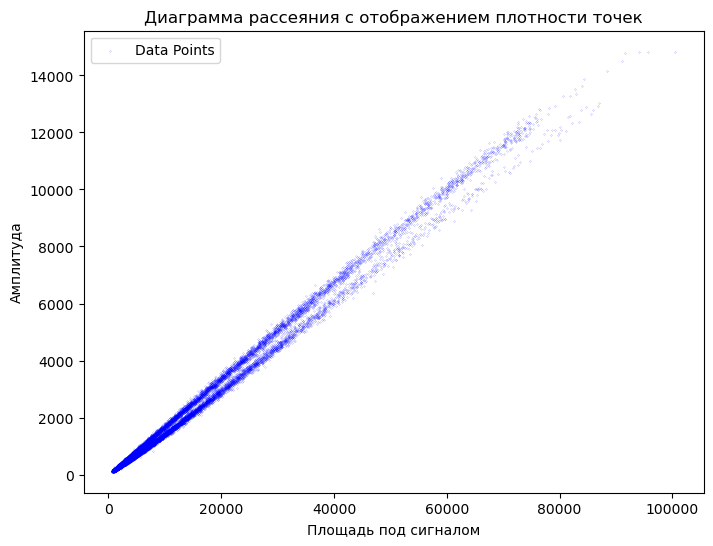

In [47]:
plt.figure(figsize=(8, 6))
plt.scatter(df['AreaUnderSignal'], df['Amplitude'], s=0.01, color='blue', label='Data Points')

plt.xlabel('Площадь под сигналом')
plt.ylabel('Амплитуда')
plt.title('Диаграмма рассеяния с отображением плотности точек')
plt.legend()
plt.show()

# Кластеризация сигналов методом PCA

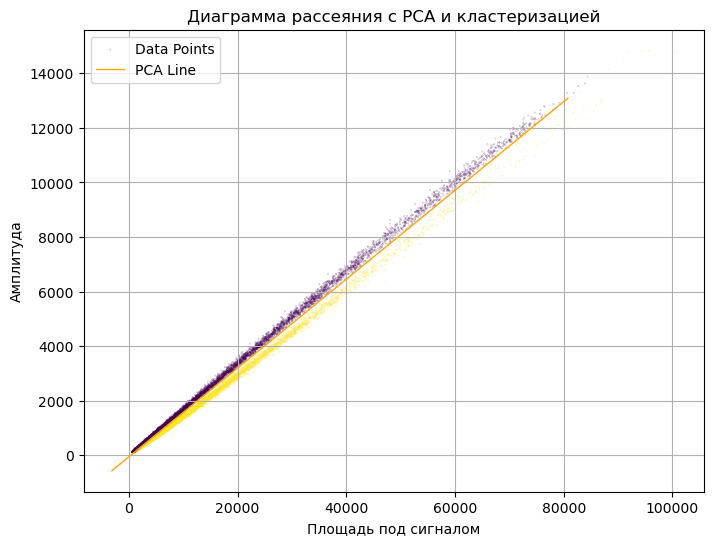

In [49]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df)

projection = pca_result[:, 1]
pca_classes = np.where(projection > 0, 1, 0)

plt.figure(figsize=(8, 6))
plt.scatter(df['AreaUnderSignal'], df['Amplitude'], c=pca_classes, cmap='viridis', s=0.01, label='Data Points')

data_mean = df.mean(axis=0)
pca_vector = pca.components_[0]
start, end = data_mean - 15000 * pca_vector, data_mean + 70000 * pca_vector
plt.plot([start[0], end[0]], [start[1], end[1]], linewidth=1, color='orange', label='PCA Line')

plt.xlabel('Площадь под сигналом')
plt.ylabel('Амплитуда')
plt.title('Диаграмма рассеяния с PCA и кластеризацией')
plt.legend()
plt.grid(True)
plt.show()

Посмотрим на меньшем масштабе - где амплитуда небольшая(там модели сложнее разделять).

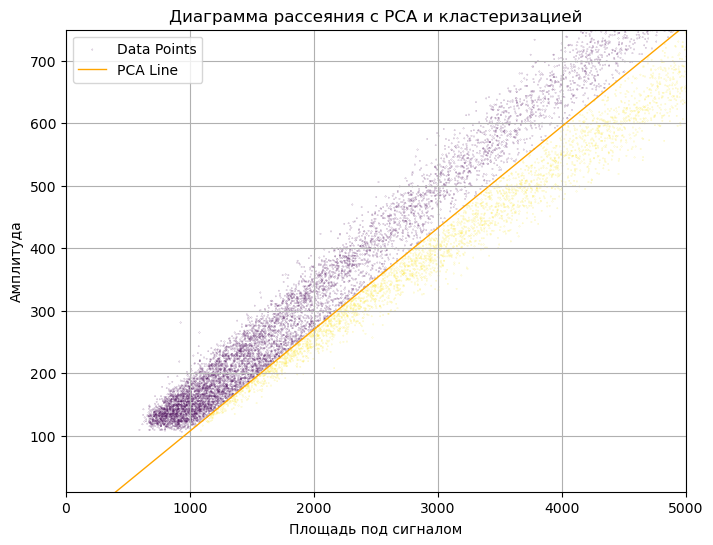

In [51]:
plt.figure(figsize=(8, 6))
plt.scatter(df['AreaUnderSignal'], df['Amplitude'], c=pca_classes, cmap='viridis', s=0.01, label='Data Points')
plt.plot([start[0], end[0]], [start[1], end[1]], linewidth=1, color='orange', label='PCA Line')

plt.xlim(0, 5000)
plt.ylim(10, 750)

plt.xlabel('Площадь под сигналом')
plt.ylabel('Амплитуда')
plt.title('Диаграмма рассеяния с PCA и кластеризацией')
plt.legend()
plt.grid(True)
plt.show()

# Публикация результата для метода PCA

Подготавливаем результат. Добавляем отброшенные ранее выбросы:

In [54]:
pca_classes_series = pd.Series(pca_classes, index=df.index, name='cluster')
anomaly_series = pd.Series(2, index=anomaly_indexes, name='cluster')
pca_cluster_classes = pd.concat([pca_classes_series, anomaly_series]).sort_index()

In [55]:
pca_cluster_classes = pd.factorize(pca_cluster_classes)[0]
submition = pd.DataFrame(pca_cluster_classes, columns=['cluster'])
submition = submition.reset_index()
submition.to_csv('session-pca-final.csv', index=False);

Не привожу здесь результаты, потому что мой лучший скор для PCA 0.58 без pd.factorize и с прибавлением единицы к pca_cluster_classes. Причем я проводил много эксперементов с этим решением и получал скоры 0.33 - 0.58. То есть как будто мне не могло так везти. Но то решение которое я оставил, выдает только 0.1, что не очень похоже на правду с учетом визуализации. Я оставляю этот код, потому что аналогичный для других моделей выдает скор 0.8+, что подтверждает правильность такого подхода.

# Публикация результата моделью GaussianMixture

По диаграмме рассеяния видно как сигналы разделяются по углу наклона по оси абсцисс. Создадим датафрейм по отношению амплитуды к площади и кластеризуем на 2 класса моделью GaussianMixture.

In [59]:
df_ratio = pd.DataFrame({
    'ratio': np.array(amplitudes) / np.array(area_under_signals),
})
df_ratio.drop(index=anomaly_indexes, inplace=True)

scaler = StandardScaler()
scaled_df = scaler.fit_transform(df_ratio)

gaussian_clustering = GaussianMixture(n_components=2, random_state=42)
gaussian_clusters = gaussian_clustering.fit_predict(scaled_df)

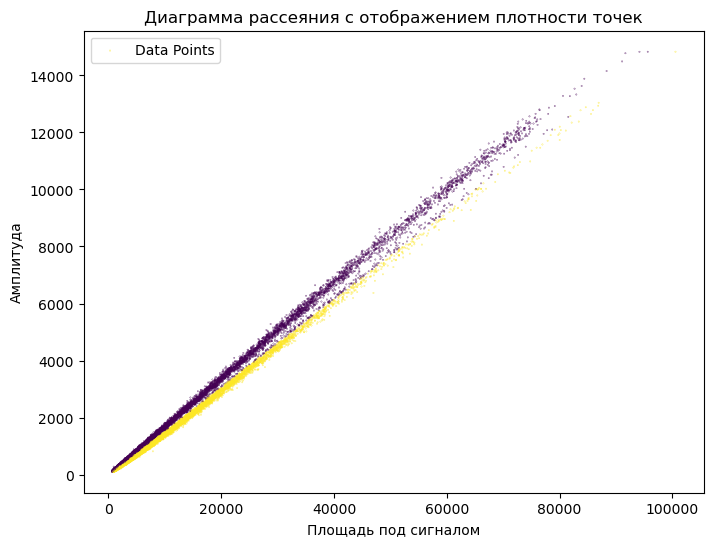

In [60]:
plt.figure(figsize=(8, 6))
plt.scatter(df['AreaUnderSignal'], df['Amplitude'], c=gaussian_clusters, cmap='viridis', s=0.05, label='Data Points')

plt.xlabel('Площадь под сигналом')
plt.ylabel('Амплитуда')
plt.title('Диаграмма рассеяния с отображением плотности точек')
plt.legend()
plt.show()

Посмотрим на меньшем масштабе, где PCA испытывала сложность с разделением.

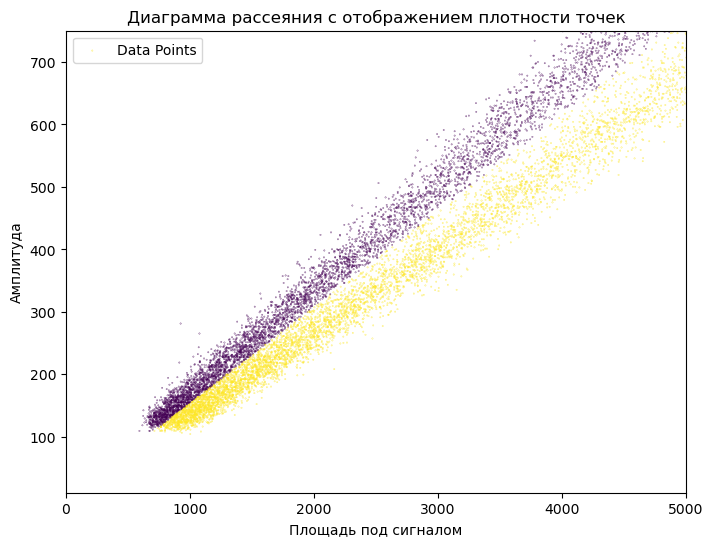

In [62]:
plt.figure(figsize=(8, 6))
plt.scatter(df['AreaUnderSignal'], df['Amplitude'], c=gaussian_clusters, cmap='viridis', s=0.05, label='Data Points')

plt.xlim(0, 5000)
plt.ylim(10, 750)

plt.xlabel('Площадь под сигналом')
plt.ylabel('Амплитуда')
plt.title('Диаграмма рассеяния с отображением плотности точек')
plt.legend()
plt.show()

Подготавливаем результат. Добавляем отброшенные ранее выбросы:

In [64]:
gaussian_clusters_series = pd.Series(gaussian_clusters, index=df.index, name='cluster')
anomaly_series = pd.Series(2, index=anomaly_indexes, name='cluster')
gaussian_cluster_classes = pd.concat([gaussian_clusters_series, anomaly_series]).sort_index()

In [65]:
gaussian_cluster_classes = pd.factorize(gaussian_cluster_classes)[0]
submition = pd.DataFrame(gaussian_cluster_classes, columns=['cluster'])
submition = submition.reset_index()
submition.to_csv('session-gaussian-final.csv', index=False);

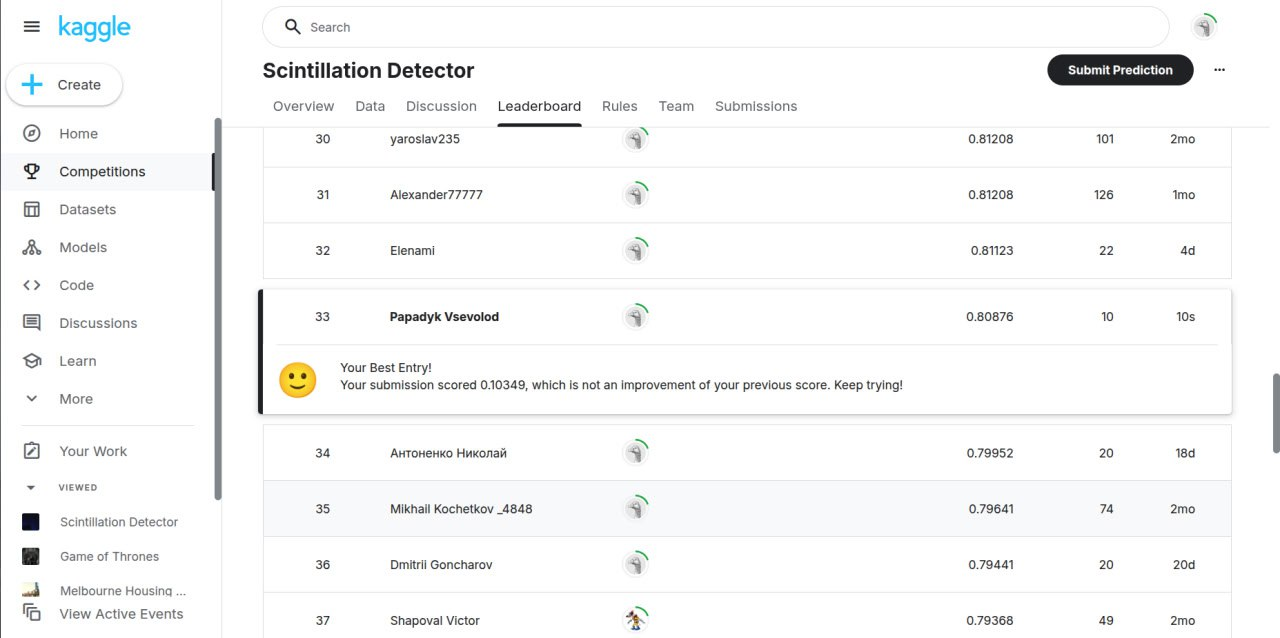

# Публикация результата моделью KMeans

In [68]:
kmeans_clustering = KMeans(n_clusters=2, random_state=42)
kmeans_clusters = kmeans_clustering.fit_predict(scaled_df)

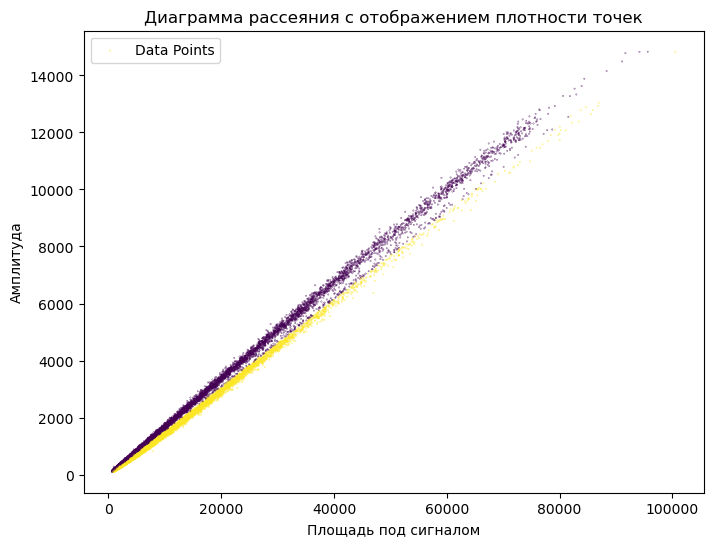

In [69]:
plt.figure(figsize=(8, 6))
plt.scatter(df['AreaUnderSignal'], df['Amplitude'], c=kmeans_clusters, cmap='viridis', s=0.05, label='Data Points')

plt.xlabel('Площадь под сигналом')
plt.ylabel('Амплитуда')
plt.title('Диаграмма рассеяния с отображением плотности точек')
plt.legend()
plt.show()

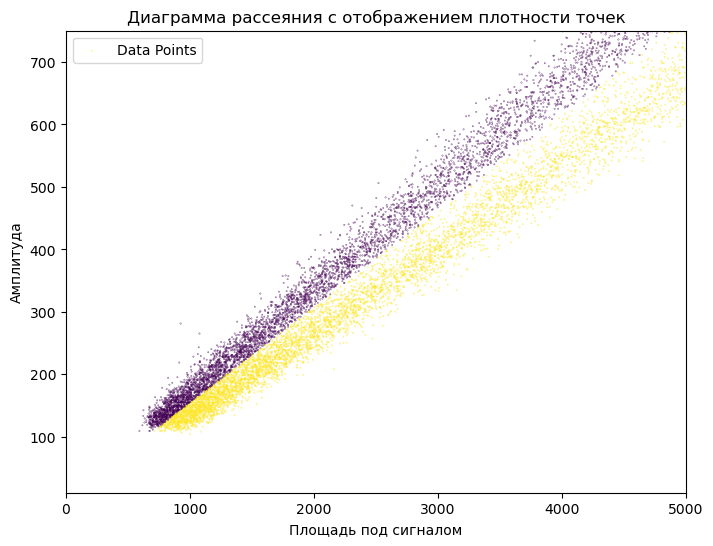

In [70]:
plt.figure(figsize=(8, 6))
plt.scatter(df['AreaUnderSignal'], df['Amplitude'], c=kmeans_clusters, cmap='viridis', s=0.05, label='Data Points')

plt.xlim(0, 5000)
plt.ylim(10, 750)

plt.xlabel('Площадь под сигналом')
plt.ylabel('Амплитуда')
plt.title('Диаграмма рассеяния с отображением плотности точек')
plt.legend()
plt.show()

In [71]:
kmeans_clusters_series = pd.Series(kmeans_clusters, index=df.index, name='cluster')
anomaly_series = pd.Series(2, index=anomaly_indexes, name='cluster')
kmeans_cluster_classes = pd.concat([kmeans_clusters_series, anomaly_series]).sort_index()

In [72]:
kmeans_cluster_classes = pd.factorize(kmeans_cluster_classes)[0]
submition = pd.DataFrame(kmeans_cluster_classes, columns=['cluster'])
submition = submition.reset_index()
submition.to_csv('session-kmeans-final.csv', index=False);

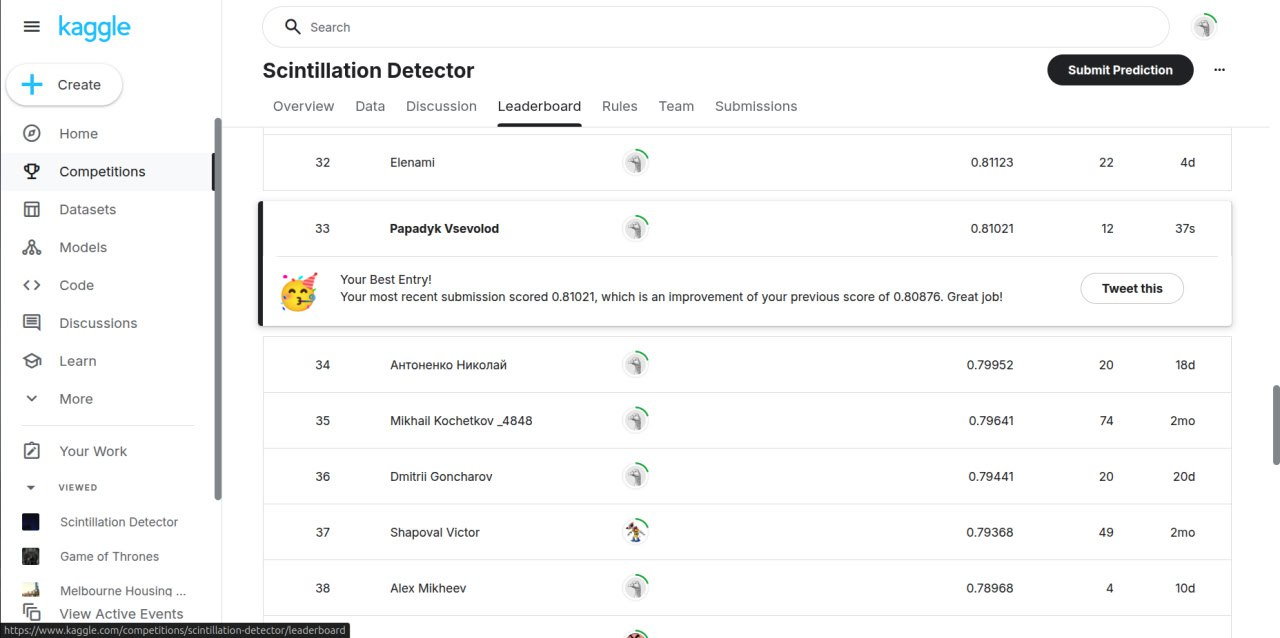

# Подбор гиперпараметров

In [75]:
init_options = ['k-means++', 'random']
max_iter_options = [300, 500, 1000]
n_init_options = [10, 20, 30]
tol_options = [1e-4, 1e-3, 1e-2]

best_score = -1
best_params = None

for init, max_iter, n_init, tol in itertools.product(init_options, max_iter_options, n_init_options, tol_options):
    kmeans = KMeans(n_clusters=2, init=init, max_iter=max_iter, n_init=n_init, tol=tol, random_state=42)
    labels = kmeans.fit_predict(scaled_df)
    
    silhouette_avg = silhouette_score(scaled_df, labels)
    
    if silhouette_avg > best_score:
        best_score = silhouette_avg
        best_params = {
            'init': init,
            'max_iter': max_iter,
            'n_init': n_init,
            'tol': tol
        }

print(f"Лучшие параметры: {best_params}")
print(f"Лучший средний силуэтный коэффициент: {best_score:.2f}")

Лучшие параметры: {'init': 'random', 'max_iter': 300, 'n_init': 20, 'tol': 0.01}
Лучший средний силуэтный коэффициент: 0.66


In [76]:
best_clustering = KMeans(n_clusters=2, init=best_params['init'], max_iter=best_params['max_iter'], n_init=best_params['n_init'], tol=best_params['tol'], random_state=42)
best_clusters = best_clustering.fit_predict(scaled_df)

best_clusters_series = pd.Series(best_clusters, index=df.index, name='cluster')
anomaly_series = pd.Series(2, index=anomaly_indexes, name='cluster')
best_cluster_classes = pd.concat([best_clusters_series, anomaly_series]).sort_index()

best_cluster_classes = pd.factorize(best_cluster_classes)[0]
submition = pd.DataFrame(best_cluster_classes, columns=['cluster'])
submition = submition.reset_index()
submition.to_csv('session-kmeans-final-hyper.csv', index=False);

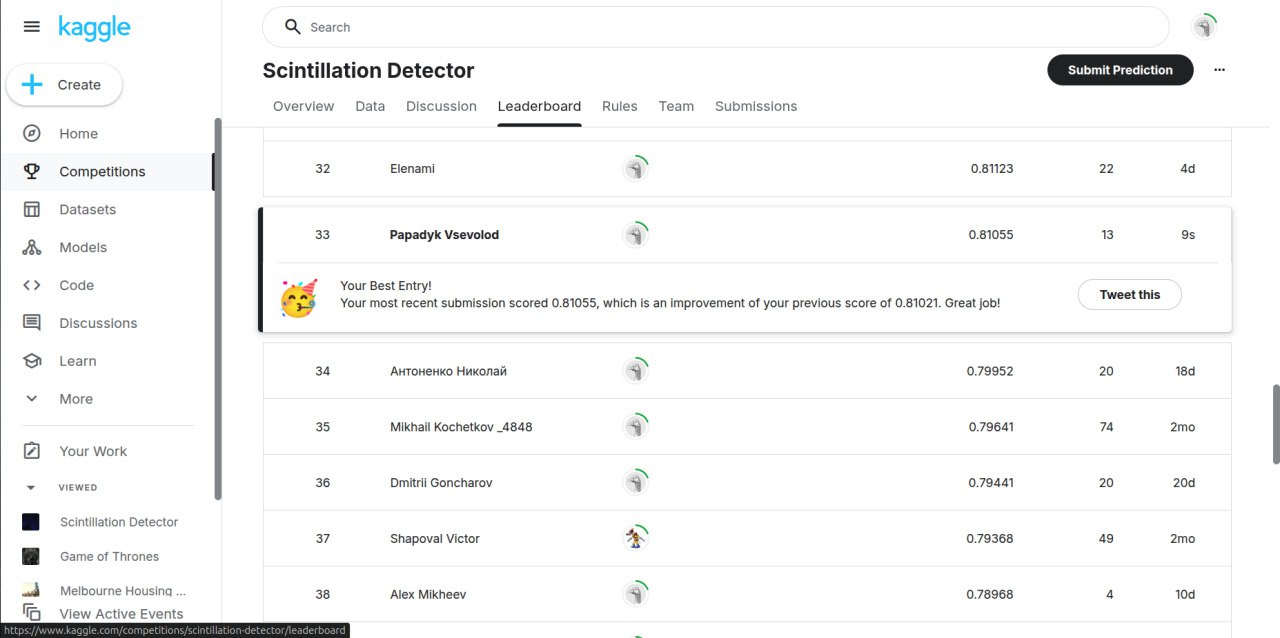

# Выводы

Кластеризовать частицы по сигналам возможно в автоматическом режиме с 80+% точностью, при чем, чем амплитуда сигнала больше, тем достовернее удается определить частицу.

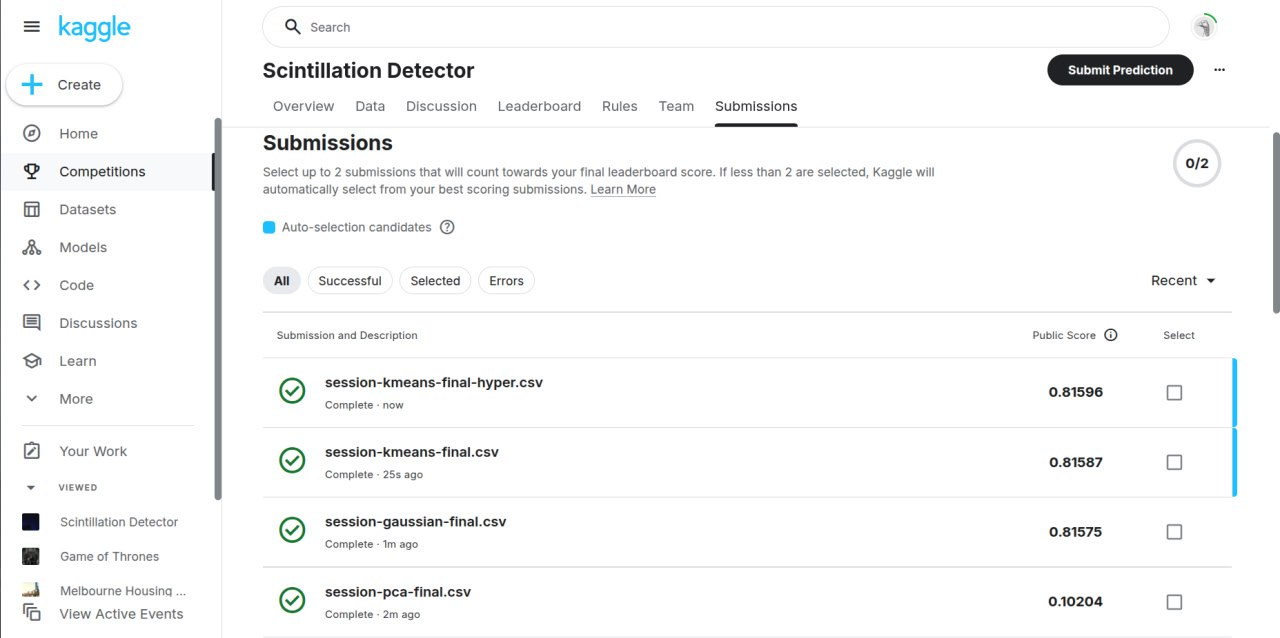